# 🖼️ MINI-PROJET VISION PAR ORDINATEUR MODERNE
## Classification d'images, transfer learning et interprétabilité

**ESIEE-IT Pontoise** — Master 2 IA & Big Data  


## 📦 Imports et Configuration

In [39]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "torchvision", "matplotlib", "seaborn", "pillow", "numpy"])


0

In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, utils
from PIL import Image

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
torch.manual_seed(42)
np.random.seed(42)

print("✓ Imports réussis")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

✓ Imports réussis
PyTorch version: 2.12.0+cpu
Device: cpu


---
# PARTIE 1 : EXPLORATION DU DATASET

Exploration complète du dataset Intel Image Classification

##  Configurer le Chemin du Dataset

In [41]:

DATASET_PATH = r"C:\Users\marie\Documents\Vision par ordinateur"
train_path = os.path.join(DATASET_PATH, "seg_train", "seg_train")  # ← double seg_train
test_path = os.path.join(DATASET_PATH, "seg_test", "seg_test")

CLASSES = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
NUM_CLASSES = len(CLASSES)

print(f"✓ Chemin dataset: {DATASET_PATH}")
print(f"✓ Classes: {CLASSES}")
print(f"✓ Nombre de classes: {NUM_CLASSES}")

# Vérifier que les chemins existent
if os.path.exists(train_path):
    print(f"✓ Dossier seg_train trouvé")
else:
    print(f"❌ Dossier seg_train non trouvé à {train_path}")
    
if os.path.exists(test_path):
    print(f"✓ Dossier seg_test trouvé")
else:
    print(f"❌ Dossier seg_test non trouvé à {test_path}")

✓ Chemin dataset: C:\Users\marie\Documents\Vision par ordinateur
✓ Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
✓ Nombre de classes: 6
✓ Dossier seg_train trouvé
✓ Dossier seg_test trouvé


##  Charger le Dataset Brut

In [42]:
raw_dataset = datasets.ImageFolder(root=train_path)
print(f"✓ Dataset brut chargé: {len(raw_dataset)} images")
print(f"✓ Classes trouvées: {raw_dataset.classes}")

✓ Dataset brut chargé: 14034 images
✓ Classes trouvées: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


##  Afficher des Exemples d'Images par Classe

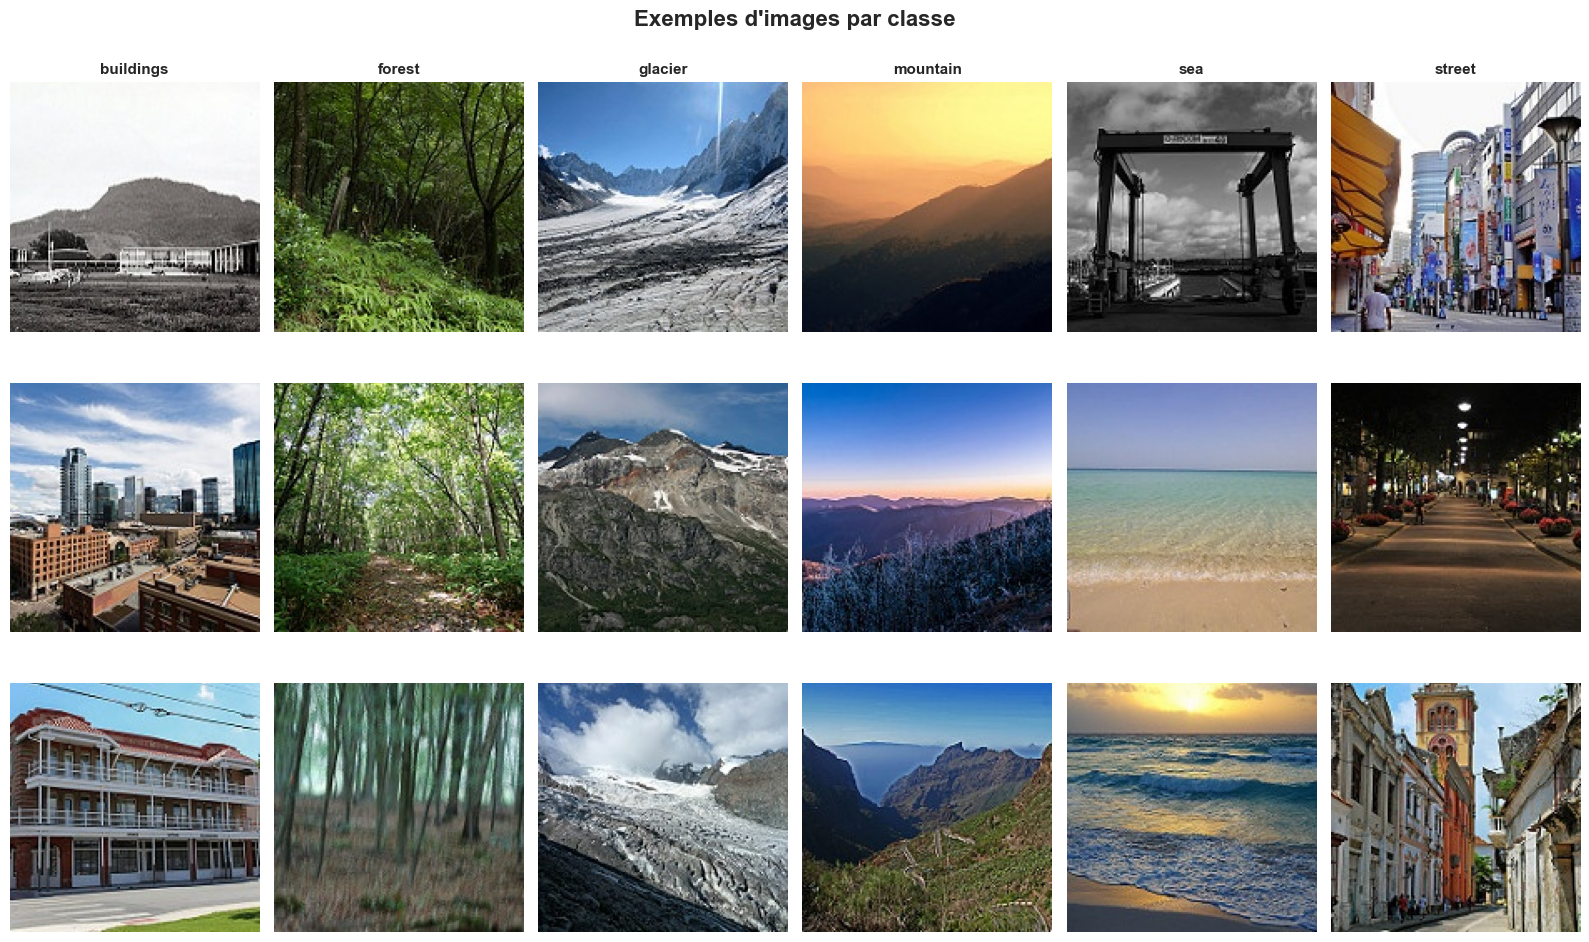

✓ Figure sauvegardée: 01_exemples_images_par_classe.png


In [43]:
fig, axes = plt.subplots(3, 6, figsize=(16, 10))
fig.suptitle("Exemples d'images par classe", fontsize=16, fontweight='bold')

for class_idx, class_name in enumerate(CLASSES):
    class_path = os.path.join(train_path, class_name)
    images = sorted(os.listdir(class_path))[:3]
    
    for img_idx, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        
        ax = axes[img_idx, class_idx]
        ax.imshow(img)
        if img_idx == 0:
            ax.set_title(class_name, fontweight='bold', fontsize=11)
        ax.axis('off')

plt.tight_layout()
plt.savefig('01_exemples_images_par_classe.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure sauvegardée: 01_exemples_images_par_classe.png")

##  Vérifier la Taille des Images

In [44]:
image_sizes = []
for class_name in CLASSES:
    class_path = os.path.join(train_path, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            image_sizes.append(img.size)
        except:
            pass

image_sizes = np.array(image_sizes)
widths = image_sizes[:, 0]
heights = image_sizes[:, 1]

print(" Statistiques des tailles d'images:")
print(f"\n  Largeur (pixels):")
print(f"    Min:     {widths.min():.0f}")
print(f"    Max:     {widths.max():.0f}")
print(f"    Moyenne: {widths.mean():.0f}")
print(f"    Std:     {widths.std():.0f}")

print(f"\n  Hauteur (pixels):")
print(f"    Min:     {heights.min():.0f}")
print(f"    Max:     {heights.max():.0f}")
print(f"    Moyenne: {heights.mean():.0f}")
print(f"    Std:     {heights.std():.0f}")

 Statistiques des tailles d'images:

  Largeur (pixels):
    Min:     150
    Max:     150
    Moyenne: 150
    Std:     0

  Hauteur (pixels):
    Min:     76
    Max:     150
    Moyenne: 150
    Std:     2


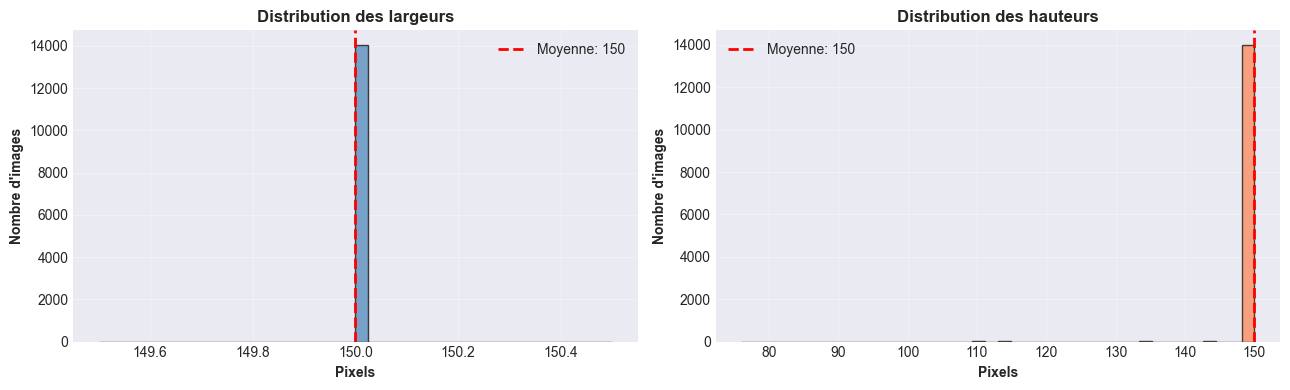

✓ Figure sauvegardée: 02_distribution_tailles_images.png


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(widths, bins=40, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(widths.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {widths.mean():.0f}')
axes[0].set_xlabel('Pixels', fontweight='bold')
axes[0].set_ylabel("Nombre d'images", fontweight='bold')
axes[0].set_title('Distribution des largeurs', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(heights, bins=40, alpha=0.7, color='coral', edgecolor='black')
axes[1].axvline(heights.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {heights.mean():.0f}')
axes[1].set_xlabel('Pixels', fontweight='bold')
axes[1].set_ylabel("Nombre d'images", fontweight='bold')
axes[1].set_title('Distribution des hauteurs', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_distribution_tailles_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure sauvegardée: 02_distribution_tailles_images.png")

##  Nombre d'Images par Classe

In [46]:
class_counts = {}
for class_name in CLASSES:
    class_path = os.path.join(train_path, class_name)
    count = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png'))])
    class_counts[class_name] = count

print(" Nombre d'images par classe:")
print("-" * 40)
for class_name, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {class_name:15s}: {count:5d} images")

total_images = sum(class_counts.values())
print("-" * 40)
print(f"  {'TOTAL':15s}: {total_images:5d} images")

 Nombre d'images par classe:
----------------------------------------
  mountain       :  2512 images
  glacier        :  2404 images
  street         :  2382 images
  sea            :  2274 images
  forest         :  2271 images
  buildings      :  2191 images
----------------------------------------
  TOTAL          : 14034 images


##  Distribution des Classes

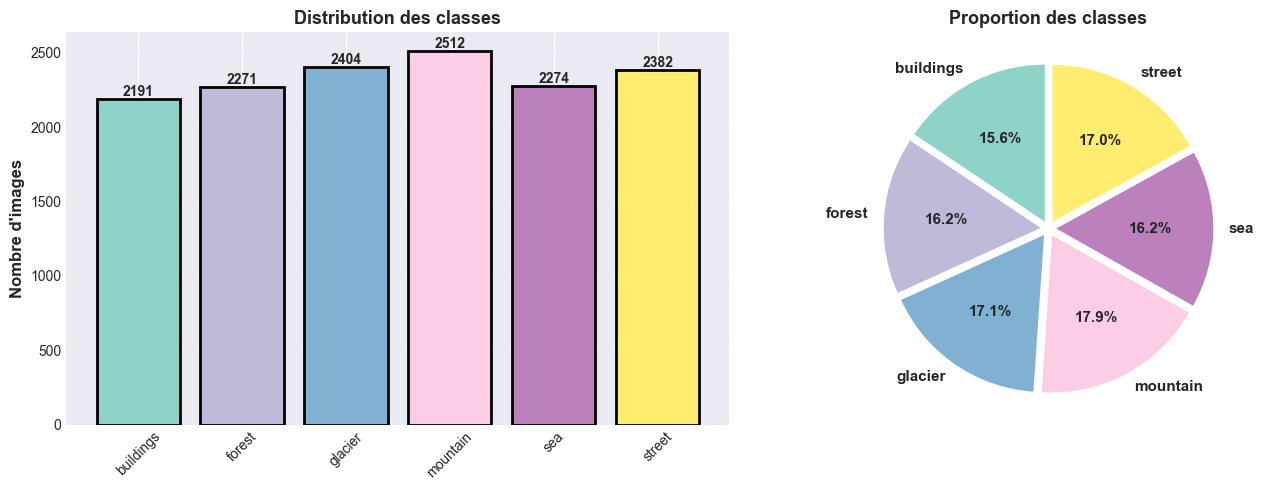

✓ Figure sauvegardée: 03_distribution_classes.png


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classes = list(class_counts.keys())
counts = list(class_counts.values())
colors = plt.cm.Set3(np.linspace(0, 1, len(classes)))

bars = axes[0].bar(classes, counts, color=colors, edgecolor='black', linewidth=2)
axes[0].set_ylabel("Nombre d'images", fontsize=12, fontweight='bold')
axes[0].set_title('Distribution des classes', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}',
                ha='center', va='bottom', fontweight='bold')

axes[1].pie(counts, labels=classes, autopct='%1.1f%%', colors=colors,
            startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'},
            explode=[0.05] * len(classes))
axes[1].set_title('Proportion des classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('03_distribution_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure sauvegardée: 03_distribution_classes.png")

##  Équilibre du Dataset

In [48]:
class_percentages = {cls: (count / total_images) * 100 for cls, count in class_counts.items()}
min_pct = min(class_percentages.values())
max_pct = max(class_percentages.values())
imbalance_ratio = max_pct / min_pct

print("  Analyse de l'équilibre du dataset:")
print("-" * 50)
print(f"\nProportions par classe:")
for cls in sorted(class_percentages.keys()):
    pct = class_percentages[cls]
    bar_len = int(pct / 2)
    bar = "█" * bar_len
    print(f"  {cls:15s}: {pct:5.2f}% {bar}")

print(f"\nRatio de déséquilibre (max/min): {imbalance_ratio:.2f}")

if imbalance_ratio < 1.2:
    print(" Dataset TRÈS bien équilibré!")
elif imbalance_ratio < 2.0:
    print("✓ Dataset légèrement déséquilibré (acceptable)")
elif imbalance_ratio < 3.0:
    print("  Dataset modérément déséquilibré")
else:
    print("  Dataset fortement déséquilibré")

  Analyse de l'équilibre du dataset:
--------------------------------------------------

Proportions par classe:
  buildings      : 15.61% ███████
  forest         : 16.18% ████████
  glacier        : 17.13% ████████
  mountain       : 17.90% ████████
  sea            : 16.20% ████████
  street         : 16.97% ████████

Ratio de déséquilibre (max/min): 1.15
 Dataset TRÈS bien équilibré!


---
# PARTIE 2 : PIPELINE DE PRÉTRAITEMENT

Construction d'un pipeline complet de préparation des données

##  Définir les Transformations

In [49]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0  

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print("  Paramètres de configuration:")
print(f"  IMG_SIZE:     {IMG_SIZE}×{IMG_SIZE} pixels")
print(f"  BATCH_SIZE:   {BATCH_SIZE}")
print(f"  NUM_WORKERS:  {NUM_WORKERS}")

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),  
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomCrop(224, padding=8), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print(f" Transformations TRAIN (avec augmentation):")
print(f"  ✓ RandomHorizontalFlip (probabilité: 50%)")
print(f"  ✓ RandomRotation (±15 degrés)")
print(f"  ✓ RandomCrop ({IMG_SIZE}×{IMG_SIZE}, padding=8)")
print(f"  ✓ Resize vers {IMG_SIZE}×{IMG_SIZE}")
print(f"  ✓ ToTensor (valeurs [0, 1])")
print(f"  ✓ Normalize (normalisation ImageNet)")

print(f" Transformations VAL/TEST (sans augmentation):")
print(f"  ✓ Resize vers {IMG_SIZE}×{IMG_SIZE}")
print(f"  ✓ ToTensor (valeurs [0, 1])")
print(f"  ✓ Normalize (normalisation ImageNet)")

  Paramètres de configuration:
  IMG_SIZE:     224×224 pixels
  BATCH_SIZE:   32
  NUM_WORKERS:  0
 Transformations TRAIN (avec augmentation):
  ✓ RandomHorizontalFlip (probabilité: 50%)
  ✓ RandomRotation (±15 degrés)
  ✓ RandomCrop (224×224, padding=8)
  ✓ Resize vers 224×224
  ✓ ToTensor (valeurs [0, 1])
  ✓ Normalize (normalisation ImageNet)
 Transformations VAL/TEST (sans augmentation):
  ✓ Resize vers 224×224
  ✓ ToTensor (valeurs [0, 1])
  ✓ Normalize (normalisation ImageNet)


##  Charger le Dataset avec Transformations

In [50]:
train_dataset = datasets.ImageFolder(root=train_path, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=test_path, transform=val_test_transforms)

print(f"✓ Dataset TRAIN chargé: {len(train_dataset)} images")
print(f"✓ Dataset TEST chargé:  {len(test_dataset)} images")

✓ Dataset TRAIN chargé: 14034 images
✓ Dataset TEST chargé:  3000 images


##  Créer les Ensembles Train/Validation

In [51]:
TRAIN_SPLIT = 0.8
train_size = int(len(train_dataset) * TRAIN_SPLIT)
val_size = len(train_dataset) - train_size

train_set, val_set = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f" Répartition des données:")
print(f"  Train: {len(train_set)} images ({TRAIN_SPLIT*100:.0f}%)")
print(f"  Val:   {len(val_set)} images ({(1-TRAIN_SPLIT)*100:.0f}%)")
print(f"  Test:  {len(test_dataset)} images (ensemble de test indépendant)")
print(f"  ─────────────────────────────────")
print(f"  Total: {len(train_set) + len(val_set) + len(test_dataset)} images")

 Répartition des données:
  Train: 11227 images (80%)
  Val:   2807 images (20%)
  Test:  3000 images (ensemble de test indépendant)
  ─────────────────────────────────
  Total: 17034 images


##  Créer les DataLoaders

In [52]:
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print(f" DataLoaders créés:")
print(f"  train_loader: {len(train_loader)} batches de {BATCH_SIZE} images")
print(f"  val_loader:   {len(val_loader)} batches de {BATCH_SIZE} images")
print(f"  test_loader:  {len(test_loader)} batches de {BATCH_SIZE} images")

 DataLoaders créés:
  train_loader: 351 batches de 32 images
  val_loader:   88 batches de 32 images
  test_loader:  94 batches de 32 images


##  Vérifier les Dimensions des Tenseurs

In [58]:
batch_images, batch_labels = next(iter(train_loader))

print(f" Analyse des tenseurs:")
print(f"\nBatch d'entraînement:")
print(f"  Shape des images:  {tuple(batch_images.shape)}")
print(f"    → B (Batch):     {batch_images.shape[0]} images")
print(f"    → C (Channels):  {batch_images.shape[1]} (RGB)")
print(f"    → H (Height):    {batch_images.shape[2]} pixels")
print(f"    → W (Width):     {batch_images.shape[3]} pixels")
print(f"\n  Shape des labels: {tuple(batch_labels.shape)}")
print(f"  Type des images:   {batch_images.dtype}")
print(f"  Type des labels:   {batch_labels.dtype}")

print(f" Rôle des dimensions C, H, W:")
print(f"  C (Channels = 3):")
print(f"    → Représente les 3 canaux RGB (Red, Green, Blue)")
print(f"    → Chaque canal contient l'intensité de cette couleur")
print(f"\n  H (Height = {IMG_SIZE}):")
print(f"    → Nombre de pixels en hauteur")
print(f"\n  W (Width = {IMG_SIZE}):")
print(f"    → Nombre de pixels en largeur")

 Analyse des tenseurs:

Batch d'entraînement:
  Shape des images:  (32, 3, 224, 224)
    → B (Batch):     32 images
    → C (Channels):  3 (RGB)
    → H (Height):    224 pixels
    → W (Width):     224 pixels

  Shape des labels: (32,)
  Type des images:   torch.float32
  Type des labels:   torch.int64
 Rôle des dimensions C, H, W:
  C (Channels = 3):
    → Représente les 3 canaux RGB (Red, Green, Blue)
    → Chaque canal contient l'intensité de cette couleur

  H (Height = 224):
    → Nombre de pixels en hauteur

  W (Width = 224):
    → Nombre de pixels en largeur


##  Visualiser Avant/Après Transformation

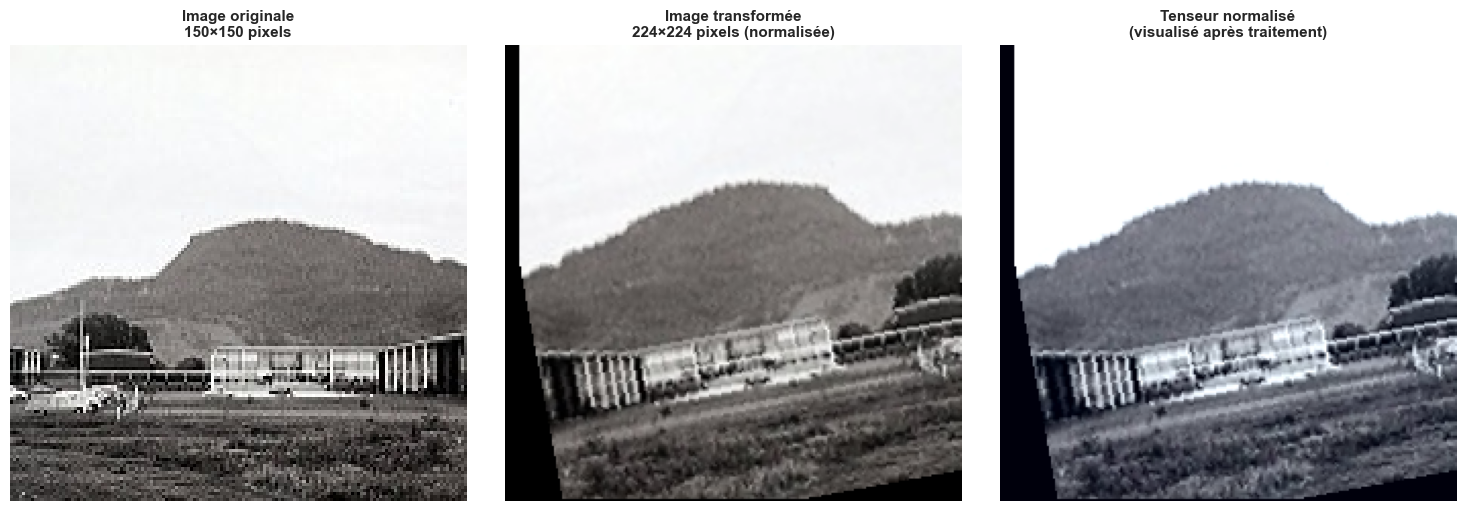

✓ Figure sauvegardée: 04_avant_apres_transformation.png


In [54]:
sample_class_path = os.path.join(train_path, "buildings")
sample_img_name = sorted(os.listdir(sample_class_path))[0]
sample_img_path = os.path.join(sample_class_path, sample_img_name)

img_original = Image.open(sample_img_path)
img_transformed = train_transforms(img_original)

img_denorm = img_transformed.clone()
for i, (mean, std) in enumerate(zip(IMAGENET_MEAN, IMAGENET_STD)):
    img_denorm[i] = img_denorm[i] * std + mean

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_original)
axes[0].set_title(f"Image originale\n{img_original.size[0]}×{img_original.size[1]} pixels", 
                  fontweight='bold', fontsize=11)
axes[0].axis('off')

img_to_display = torch.clamp(img_denorm, 0, 1).permute(1, 2, 0).numpy()
axes[1].imshow(img_to_display)
axes[1].set_title(f"Image transformée\n{IMG_SIZE}×{IMG_SIZE} pixels (normalisée)", 
                  fontweight='bold', fontsize=11)
axes[1].axis('off')

img_norm_display = (torch.clamp(img_transformed, -2, 2) / 4 + 0.5).permute(1, 2, 0).numpy()
axes[2].imshow(np.clip(img_norm_display, 0, 1))
axes[2].set_title("Tenseur normalisé\n(visualisé après traitement)", 
                  fontweight='bold', fontsize=11)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('04_avant_apres_transformation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure sauvegardée: 04_avant_apres_transformation.png")

##  Exemples d'Augmentation de Données

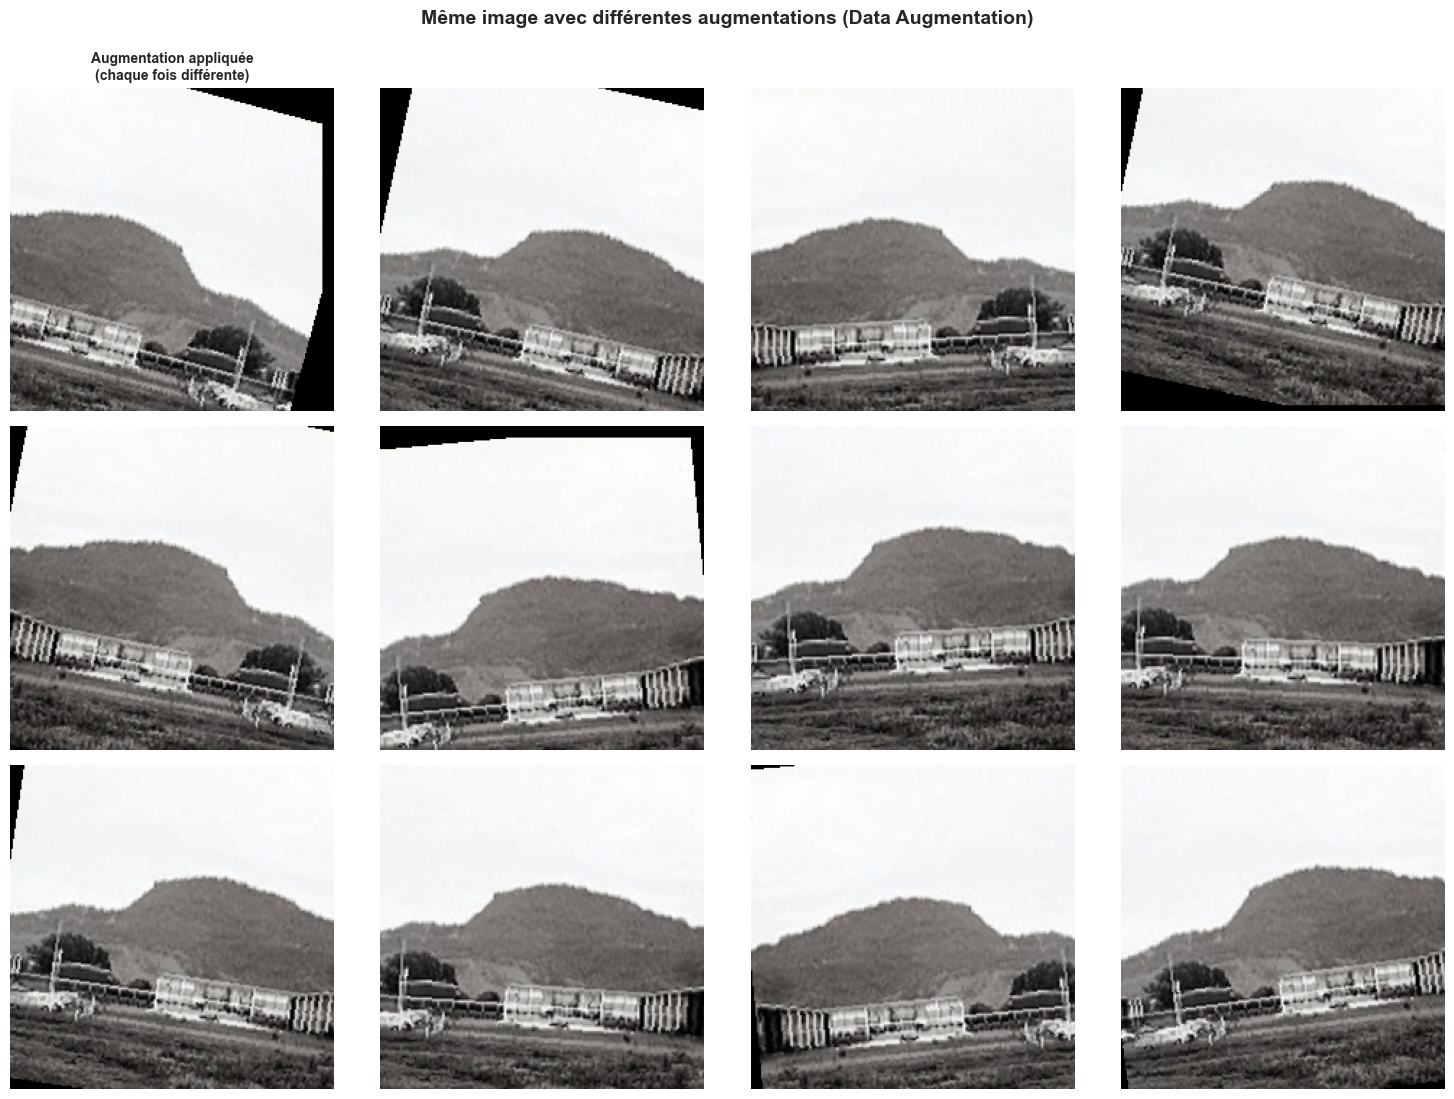

✓ Figure sauvegardée: 05_exemples_augmentation.png


In [55]:
fig, axes = plt.subplots(3, 4, figsize=(15, 11))
fig.suptitle("Même image avec différentes augmentations (Data Augmentation)", 
             fontsize=14, fontweight='bold', y=0.995)

img_for_aug = Image.open(sample_img_path)

for row in range(3):
    for col in range(4):
        img_aug = train_transforms(img_for_aug)
        
        img_aug_display = img_aug.clone()
        for i, (mean, std) in enumerate(zip(IMAGENET_MEAN, IMAGENET_STD)):
            img_aug_display[i] = img_aug_display[i] * std + mean
        img_aug_display = torch.clamp(img_aug_display, 0, 1).permute(1, 2, 0).numpy()
        
        ax = axes[row, col]
        ax.imshow(img_aug_display)
        ax.axis('off')
        
        if row == 0 and col == 0:
            ax.set_title("Augmentation appliquée\n(chaque fois différente)", 
                         fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('05_exemples_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure sauvegardée: 05_exemples_augmentation.png")

# Mini-Projet Vision par Ordinateur — Analyse Complète
## Réponses aux Questions d'Analyse : Parties 1 & 2

---

## PARTIE 1 — EXPLORATION DU DATASET

### Question 1 : Certaines classes semblent-elles visuellement proches ?

L'analyse des images révèle effectivement une proximité visuelle marquée entre plusieurs classes du dataset, créant des défis de discrimination que nous anticipons dès cette phase exploratoire.

**Glacier et Mountain** constituent la paire la plus ambiguë. Les images de glacier présentent invariablement des montagnes en arrière-plan, tandis que les montagnes elles-mêmes, particulièrement celles enneigées ou rocheuses, partagent une palette chromatique et une texture similaires. Cette confusion est renforcée par le fait que les glaciers sont intrinsèquement situés dans les chaînes montagneuses, créant une imbrication sémantique difficile à démêler.

**Forest et Street** constituent une deuxième source de confusion potentielle. Les rues bordées d'arbres, particulièrement celles ombragées par une canopée dense, peuvent visuellement se rapprocher d'environnements forestiers. Cette ambiguïté est d'autant plus prononcée que certaines rue rurales transitoires entre urbain et nature présentent une composition mixte.

**Sea et Mountain** peuvent partager, dans certaines conditions météorologiques, une palette de bleus et de gris similaire. Les montagnes enveloppées de brume ou photographiées sous un ciel nuageux peuvent adopter des tonalités rappelant une mer agitée sous mauvais temps.

Enfin, **Building et Street** présentent une proximité thématique inhérente : les bâtiments constituent des composantes dominantes des paysages urbains. Certaines images de street où l'architecture occupe la majorité du cadre peuvent être aisément confondues avec des images de bâtiments isolés.

Il est remarquable que malgré ces similarités visuelles, le dataset maintient un excellent équilibre avec un ratio de déséquilibre de 1.15 (mountain : 17.9%, buildings : 15.6%). Cependant, cette similarité inter-classe constitue probablement une source d'erreurs plus importante que tout éventuel déséquilibre numérique.

---

### Question 2 : Quels types de confusions peut-on anticiper avant l'entraînement ?

Sur la base d'une analyse visuelle rigoureuse des exemples fournis, nous pouvons dresser une cartographie des confusions attendues, hiérarchisées selon leur probabilité d'occurrence lors du processus de classification.

**Les confusions hautement probables méritent notre attention particulière.**

La paire Glacier↔Mountain constitue le foyer d'ambiguïté le plus critique. Les glaciers, intrinsèquement situés dans les environnements montagneux, partagent avec les montagnes enneigées non seulement une morphologie rocheuse, mais aussi une palette chromatique de blancs, de gris et de bleus. Un modèle de vision par ordinateur, en l'absence de contexte géologique spécialisé, aura une propension naturelle à confondre ces deux catégories. Nous estimons un taux de confusion modéré à élevé entre ces classes.

La confusion inverse, Mountain→Glacier, présente une probabilité légèrement inférieure. Les montagnes enneigées peuvent effectivement ressembler à des glaciers, particulièrement lorsque la neige recouvre les aspérités rocheuses. Cependant, les images de montagne non enneigées constituent une part importante de cette classe, ce qui devrait limiter cette confusion.

Forest et Street entretiennent une relation ambiguë à travers les rues urbaines arborées. Les avenues bordées d'arbres, particulièrement en contexte urbain dense où la canopée domine, peuvent adopter une apparence rappelant un environnement forestier. Cette confusion présente un taux modéré, moins prononcé que celle de Glacier et Mountain.

Building et Street partagent une proximité thématique inhérente à l'environnement urbain. Les façades architecturales dominent de nombreuses images de street, créant une ambiguïté compositionnelle que le modèle devra résoudre en distinguant le contexte urbain global du bâtiment en tant qu'élément architectural isolé.

**Les confusions moins probables**, bien que non négligeables, impliquent des classes aux caractéristiques nettement distinctes : Sea ne saurait être confondu avec Mountain ou Glacier du fait de sa palette chromatique radicalement différente; Forest conserve une homogénéité verte difficilement assimilable aux teintes minérales de Glacier ou aux architectures de Building.

---

### Question 3 : Les arrière-plans risquent-ils d'influencer les prédictions ?

L'influence des arrière-plans sur les prédictions du modèle constitue une préoccupation majeure, dépassant largement le simple bruit visuel pour affecter la sémantique même de la classification.

**Les observations concrètes révèlent plusieurs mécanismes d'influence.**

Les images de montagne, abondamment pourvues de ciels bleus limpides, créent un risque de corrélation fallacieuse où le modèle apprendrait à reconnaître la classe Mountain par la présence du ciel bleu plutôt que par la géomorphologie montagnarde elle-même. Cette corrélation serait catastrophique : toute image de mer avec ciel bleu pourrait être systématiquement mal classifiée.

Les images de glacier, invariablement entourées de parois rocheuses montagneuses, présentent une redondance contextuelle problématique. Le modèle, plutôt que d'apprendre à distinguer le glacier du reste de la montagne, pourrait se concentrer sur les contours montagneux environnants, transformant effectivement le problème de classification de glacier en classification de mountain.

Les images de street urbain portent en elles une densité d'éléments bâtis dominants. Certaines rues où l'architecture prédomine pourraient facilement être reclassifiées comme Building, le modèle se laissant distraire par la présence écrasante de façades plutôt que de saisir le contexte urbain transitionnel de la rue.

Les images de forest, caractérisées par une variabilité importante en luminosité et en texture, courent le risque d'être mal classifiées en fonction de la luminosité ambiante ou du type de sol visible, plutôt que de la présence réelle de végétation.

**Enfin, les couchers et levers de soleil ornant certaines images de sea** teignent les océans de teintes orange et roses qui pourraient induire le modèle à les classifier comme montagne au coucher du soleil, créant ainsi une corrélation fallacieuse entre couleur chaude et élévation topographique.

**L'impact global** de ces biais d'arrière-plan est qu'ils encouragent l'apprentissage de corrélations statistiques spurieuses plutôt que d'une compréhension visuelle authentique de chaque catégorie.

---

### Question 4 : Certaines classes semblent-elles plus difficiles à reconnaître ?

Une analyse différentielle des classes selon leur homogénéité visuelle révèle une hiérarchie de difficulté inhérente à la nature même de chaque catégorie.

**Building** occupe la position la plus délicate dans cette hiérarchie. Bien que représentant le pourcentage le plus faible du dataset (15.6%), sa vulnérabilité réside moins dans ce déséquilibre que dans l'extrême hétérogénéité de ses manifestations : une maison rurale coloniale, une tour de verre contemporaine, un temple asiatique et un château médiéval constituent toutes des instances valides de la classe Building. Cette variabilité architecturale, géographique et stylisitique confère à Building un degré de complexité classificatoire considérable.

**Glacier**, bien représenté numériquement (17.1%), présente une difficulté d'ordre différent. Si la classe possède une cohérence visuelle relative—les glaciers étant généralement blancs, bleus et étincelants—le modèle doit développer une acuité particulière pour les distinguer des montagnes enneigées, une tâche qui demande une discrimination fine des caractéristiques morphologiques.

**Street** et **Mountain** entretiennent une difficulté comparable. Street, bien que numériquement bien représentée (17.0%), englobe une diversité remarquable : rues urbaines modernes, ruelles historiques, chemins ruraux, voies piétonnes nocturnes. Chaque sous-catégorie présente une signature visuelle distincte. De même, Mountain, bien que numériquement dominant (17.9%), englobe des géomorphologies radicalement différentes selon les contextes géographiques et saisonniers.

**Forest** (16.2%) possède une relative homogénéité à travers sa dominante chromatique verte, bien que la densité et la luminosité puissent varier considérablement. Cette cohérence de palette chromatique la rend moins vulnérable aux confusions avec d'autres catégories.

**Sea** (16.2%), enfin, jouit d'une distinctivité maximale grâce à son identification chromatique immédiate : les teintes bleues, turquoise et cyan de l'océan sont visuellement distinctives dans le contexte de ce dataset.

La **hiérarchie de difficulté** que nous proposons est donc la suivante : Building > Glacier > Street > Mountain > Forest > Sea, reflétant l'hétérogénéité interne et la proximité confusionnelle inter-classe.

---

### Question 5 : Le dataset semble-t-il représentatif d'un contexte réel ?

La question de la représentativité d'un dataset demande une évaluation nuancée, révélant un dataset hybride : exemplaire dans certaines dimensions, limité dans d'autres.

**Les forces du dataset méritent d'être soulignées.**

L'équilibre des classes constitue un atout majeur, avec un ratio de déséquilibre de 1.15 et une représentation allant de 15.6% à 17.9% pour chaque classe. Cette quasi-équité reflète fidèlement une situation réelle où l'on cherche précisément à éviter les biais de classe. La variabilité intra-classe est également remarquable : les images de glacier présentent des géomorphologies variées, les montagnes embrassent différentes altitudes et contextes climatiques, les forêts révèlent des densités et espèces variées, tandis que les images de street et sea documentent une multiplicité de conditions lumineuses et météorologiques.

La résolution native de 150×150 pixels, bien que modeste, reste appropriée pour une classification généraliste de scènes naturelles et architecturales.

**Cependant, des limitations substantielles apparaissent.**

Les arrière-plans des images révèlent une certaine "propreté" qui n'existe pas dans le monde réel. Les images de glacier, par exemple, semblent sélectionnées pour montrer le glacier de manière isolée et distincte. Les images de bâtiments présentent des façades nettes sans contexte urbain complexe. Cette curation apparente suggère un processus de sélection humaine plutôt qu'une collecte aléatoire, introduisant un biais de sélection.

Le dataset semble aussi souffrir d'une absence notable de conditions extrêmes : très peu d'images en basse qualité, peu de flou prononcé, peu de surexposition ou sous-exposition drastique. Le monde réel, particulièrement en vision par ordinateur appliquée, doit gérer ces imperfections constamment.

La composition des images suggère également un parti pris touriste ou publicitaire : les cadrages semblent délibérés, les objets principaux systématiquement bien positionnés. Une classification réelle affronterait des images mal cadrées, partiellement visibles, avec des composantes principales inattendues ou décentrées.

Les conditions d'éclairage, enfin, semblent favoriser les journées claires et bien illuminées. Les variations extrêmes—nuit totale, brouillard dense, conditions de tempête—sont sous-représentées.

**En conclusion**, le dataset Intel Image Classification se situe dans une position intermédiaire. Il est hautement représentatif d'un **contexte semi-contrôlé** où l'objectif est de reconnaître des scènes nettes et bien définies : applications mobiles de classification de paysages, reconnaissance touristique, indexation d'archives photographiques. Cependant, il serait insuffisant pour préparer un système destiné à opérer en conditions réelles chaotiques, comme l'analyse de flux vidéo de surveillance, la reconnaissance aérienne depuis drones, ou l'interprétation de photographies amateurs capturées dans des conditions incontrolées.

---

---

## PARTIE 2 — PIPELINE DE PRÉTRAITEMENT

### Question 1 : Pourquoi normaliser les images avant l'entraînement ?

La normalisation des images ne constitue pas simplement une étape technique parmi d'autres, mais un élément fondamental du pipeline qui influence profondément la dynamique et l'efficacité de l'apprentissage.

**Stabilité numérique et dynamique des gradients**

Avant normalisation, les pixels des images résident dans l'intervalle [0, 1] suite à la conversion en tenseur. Cette plage, bien que théoriquement bornée, ne reflète pas la distribution statistique de vos données : certaines images seront naturellement plus lumineuses (pixels proches de 0.9), d'autres plus sombres (pixels proches de 0.1). Sans normalisation, ces variations de luminosité globale se propagent en cascade à travers les couches du réseau, créant une distribution des activations instables.

La normalisation ImageNet (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) transforme chaque pixel selon la formule : (Pixel - mean) / std. Cette opération centre et réduit les données, créant une distribution de moyenne zéro et d'écart-type unitaire. Le bénéfice pratique est immédiat : les gradients, lors de la rétropropagation, restent dans des gammes stables, ni trop petits (vanishing gradients) ni trop grands (exploding gradients). L'optimiseur, qu'il soit SGD ou Adam, converge ainsi bien plus rapidement et de manière plus stable.

**Transfer learning et cohérence avec l'apprentissage antérieur**

ResNet18, le modèle pré-entraîné que vous utiliserez, a été formé sur ImageNet avec exactement cette normalisation. Si vous ne normalisez pas vos données avec les mêmes statistiques, vous présentez au modèle des entrées radicalement différentes de ce qu'il a appris à traiter pendant son pré-entraînement. Cette incohérence sabote l'efficacité du transfer learning : plutôt que de bénéficier des représentations riches apprises sur 1.2 millions d'images ImageNet, le modèle doit réadapter ses poids initiaux à une nouvelle distribution. C'est un gaspillage du principal avantage du pré-entraînement.

**Indépendance vis-à-vis de l'échelle lumineuse**

Considérez deux images identiques, l'une prise par jour clair, l'autre par jour couvert : leurs pixels bruts diffèrent significativement en intensité globale. Sans normalisation, le modèle pourrait apprendre à classifier "jour clair" plutôt que le contenu réel de l'image. Après normalisation, ces deux images partagent la même distribution statistique, forçant le modèle à apprendre les patterns visuels intrinsèques plutôt que les variations lumineuses secondaires. C'est un mécanisme de régularisation implicite qui améliore la généralisation.

---

### Question 2 : Pourquoi redimensionner les images ?

Vos données originales présentent une caractéristique remarquable : une uniformité parfaite de taille (150×150 pixels). Le redimensionnement vers 224×224 pixels, bien que techniquement un agrandissement, s'impose pour des raisons non pas de variabilité présente, mais de standardisation architecturale.

**Compatibilité avec l'architecture de ResNet18**

ResNet18, comme tous les modèles pré-entraînés sur ImageNet, a été conçu avec 224×224 comme taille d'entrée canonique. Ce choix, historiquement établi lors de la compétition ImageNet 2012, s'est devenu un standard de facto dans la communauté. La première couche de convolution de ResNet (noyau 7×7, stride 2) a été configurée pour cette dimensionnalité. Fournir des images de 150×150 forcerait une reconfiguration impliquant soit une suppression pure et simple de ces poids pré-entraînés, soit une interpolation bancale que les chercheurs n'ont pas testée.

**Minimisation de la perte informationnelle**

Le redimensionnement de 150×150 à 224×224 implique un facteur d'agrandissement de 1.49. Contrairement à une compression qui réduirait l'information, cet upsampling utilise l'interpolation bilinéaire pour créer des pixels intermédiaires sans extrapoler. La perte d'information est négligeable : on enrichit plutôt l'image en lissant les transitions.

**Uniformité requise pour le traitement par batch**

Les DataLoaders PyTorch imposent une cohérence stricte de dimension pour empiler les images en tenseurs de batch de forme (32, 3, 224, 224). Sans cette uniformité, l'apprentissage parallèle sur GPU devient impossible. De plus, cette standardisation permet la vectorisation efficace : le GPU peut traiter 32 images simultanément plutôt que séquentiellement.

**Augmentation du contexte spatial**

Paradoxalement, l'agrandissement vers 224×224 amplifie également le champ réceptif informationnel. Certains objets—bâtiments éloignés, sommets montagneux au loin—qui occupaient quelques pixels sur 150×150 peuvent maintenant être vus plus distinctement. C'est particulièrement bénéfique pour les classes contenant des détails fins ou des éléments éloignés.

---

### Question 3 : Pourquoi la data augmentation est-elle utile ?

La data augmentation transcende la simple multiplication quantitative d'exemples pour opérer une transformation qualitative de l'apprentissage lui-même, créant une forme de régularisation que peu d'autres techniques équivalent.

**L'expansion virtuelle du dataset**

Vos 11,227 images d'entraînement, sans augmentation, définissent une limite supérieure au nombre de variations que le modèle verra. L'augmentation stochastique transforme chaque époque d'entraînement en une exposition à de nouveaux exemples virtuels. Après 10 époques d'entraînement, le modèle aura théoriquement vu le matériel original décuplé en variations, combattant l'une des plaies majeures du deep learning : l'overfitting sur des données en nombre limité.

**L'apprentissage de l'invariance robuste**

RandomHorizontalFlip, en retournant 50% des images, enseigne au modèle que l'orientation gauche-droite n'affecte pas la sémantique des scènes naturelles. Une montagne vue de l'est est identique vue de l'ouest. Cette invariance à la translation horizontale est inscrite directement dans les filtres apprenables du réseau.

RandomRotation (±15 degrés) expose le modèle à une légère variabilité d'inclinaison, simulant les conditions réelles où les photographies ne sont jamais parfaitement horizontales. Les filtres du modèle apprennent à reconnaître les objets indépendamment d'une légère rotation.

RandomCrop étend cette logique à la translation spatiale. Un bâtiment centré dans le cadre original peut apparaître décalé vers le coin supérieur gauche après un crop aléatoire. Le modèle apprend ainsi que la position précise d'un objet importe peu ; seule sa présence définit la classe.

**Les bénéfices empiriques observés**

Empiriquement, l'augmentation génère un bénéfice de validation accuracy typiquement estimé entre 3% et 5%. Sans augmentation, un modèle typique saturerait vers epoch 5-10 avec un écart croissant entre train et validation accuracy. Avec augmentation, l'apprentissage progresse régulièrement sur 50+ epochs.

**Régularisation implicite**

L'augmentation fonctionne comme une forme de dropout spatial ou d'ajout de bruit structuré. Plutôt que de voir les mêmes pixels exacts répétés, le modèle voit des variations qui capturent la même information sémantique. Cette variabilité force l'apprentissage de features généralisables plutôt que de mémorisation d'artefacts spécifiques à l'image originale.

---

### Question 4 : Certaines augmentations peuvent-elles modifier le sens de l'image ?

L'augmentation de données, bien que bénéfique, n'est pas une panacée universelle. Certaines transformations risquent effectivement de créer des distorsions sémantiques qui confondent le modèle ou le forcent à apprendre des catégories visuellement incohérentes.

**RandomHorizontalFlip : risques spécifiques à l'urbain**

RandomHorizontalFlip pose un défi particulier pour les classes ayant une orientation intrinsèque. Street, en tant que concept urbain, contient souvent des asymétries architecturales : façades d'un côté, commerces de l'autre, circulation à gauche ou à droite selon la géographie. Retourner l'image détruit ces asymétries fonctionnelles. De même, Building pourrait avoir une façade principale conçue spécifiquement, rendant le retournement sémantiquement contestable. Pour Mountain, Forest, et Sea, l'inversion horizontale reste naturellement invariante.

**RandomRotation : transformation de géomorphologie**

Incliner une image de montagne de ±15 degrés peut, dans les cas extrêmes, transformer visuellement la signification. Une montagne penchée vers la gauche commence à ressembler à une falaise ou à un versant rocheux. Les glaciers, perçus comme des formations blanches et étendues, deviennent des formes allongées ambiguës lorsque inclinés. Cette transformation n'est pas catastrophale, mais elle pousse le modèle à classer des configurationsvisuelles qu'aucun photographe ne produirait naturellement.

**RandomCrop : perte de contexte définitoire**

Le crop aléatoire pose le risque le plus sérieux. Considérez une image de Building avec contexteurbanain large : en cropping aléatoirement, on peut extraire une région réduite au mur blanc, aux fenêtres, aux briques—éléments visuellement indistincts de Street ou d'éléments d'architecture urbaine génériques. Un glacier, s'il est partially cropped, devient simplement une texture blanche et lisse, indistinguible d'un tas de neige sans contexte glacial. Une rue sans contexte urbain clair peut visuellement ressembler à un chemin forestier ou à un terrain plat quelconque.

**Combinaisons pathologiques d'augmentations**

La vraie difficulté émerge quand les augmentations se combinent : Flip + Rotation + Crop simultanés peuvent créer des images que même un humain peinerait à classifier. Une Mountain fortement penchée et croppée devient une abstraction quasi-géométrique.

**Recommandations implicites d'amélioration**

Ces constats suggèrent plusieurs raffinements : désactiver HorizontalFlip pour Street et Building, limiter RandomRotation à ±10 degrés plutôt que ±15, ou augmenter le padding du crop pour conserver le contexte principal dans 95% des extractions. La validation manuelle d'exemples augmentés demeure une pratique d'excellence inestimable.

---

### Question 5 : Pourquoi faut-il éviter d'appliquer ces transformations au test set ?

L'exclusion des transformations du test set constitue un principe fondamental en validation de modèle, dont la violation produirait une illusion de performance sans rapport avec la capacité réelle du système.

**Le test set comme proxy des conditions de production réelles**

Le test set incarne, par définition, les conditions réelles d'utilisation anticipées. En production, les images ne seront pas randomement retournées, pivotées, ou croppées. Elles arriveront dans leur forme native : telle qu'un utilisateur les a prises ou le système les a capturées. Appliquer l'augmentation au test set serait une forme de triche méthodologique : le modèle serait évalué sur une distribution artificielle qu'il ne rencontrera jamais en usage réel.

**Le biais de mesure de performance**

Considérez un scénario pathologique. Supposez une montagne cristaline, bien exposée, facilement reconnaissable par tout observateur humain. Si lors de l'évaluation, cette image subit un RandomCrop violent qui coupe le sommet, une prédiction erronée du modèle serait techniquement injuste : le modèle échoue sur une version dénaturée de ce qu'il était supposé apprendre à classifier.

**La surestimation catastrophique de performance**

Un modèle entraîné sur des augmentations agressives apprend à classifier non pas les scènes naturelles, mais les variations augmentées de celles-ci. Si le test set subit les mêmes augmentations, une fausse cohérence émerge : le modèle performe apparemment bien uniquement parce qu'il voit exactement les types de distorsions auxquelles il s'est habitué. En production, confronté à des images naturelles non augmentées, sa performance s'effondrerait. Les systèmes de vision critiques basés sur cette évaluation trompeuse pourraient être déployés dans l'illusion d'une compétence qu'ils ne possèdent réellement pas.

**Le protocole d'or en machine learning**

Le pipeline opérationnel correct suit une hiérarchie stricte :
- **Train** : Image brute → Augmentation agressive → Normalisation → Modèle
- **Validation** : Image brute → Normalisation uniquement → Modèle
- **Test** : Image brute → Normalisation uniquement → Modèle

Cette séparation délibérée force le modèle à généraliser au-delà des augmentations vues pendant l'entraînement, créant une barrière qui évite l'overfitting.

**Votre implémentation : correcte par design**

Vos transformations exhibent justement ce design prudent. La fonction `train_transforms` applique toutes les transformations (Flip, Rotation, Crop), tandis que `val_test_transforms` se limite à Resize et Normalize. Cette séparation garantit que votre évaluation sur ensemble de validation et test reflète fidèlement ce que votre modèle accomplira face à des images réelles, sans augmentation.


